In [1]:

import seaborn as sns

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report

In [2]:
tipsdf = sns.load_dataset('tips')
tipsdf.head(2)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3


In [3]:
smoker_bin = pd.factorize(tipsdf['smoker'])
tipsdf['smoker_bin'] = smoker_bin[0]
tipsdf.head(2)

,total_bill,tip,sex,smoker,day,time,size,smoker_bin
0,16.99,1.01,Female,No,Sun,Dinner,2,0
1,10.34,1.66,Male,No,Sun,Dinner,3,0


In [4]:
X = tipsdf[['total_bill']]
y = tipsdf['smoker_bin']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y)

model_dt = DecisionTreeClassifier()
model_lr = LogisticRegression()

model_dt.fit(X_train, y_train)
model_lr.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)
y_pred_lr = model_lr.predict(X_test)

cr_dt = classification_report(y_test,y_pred_dt)
cr_lr = classification_report(y_test,y_pred_lr)

print(cr_dt)
print(cr_lr)

              precision    recall  f1-score   support

           0       0.59      0.62      0.61        37
           1       0.36      0.33      0.35        24

    accuracy                           0.51        61
   macro avg       0.48      0.48      0.48        61
weighted avg       0.50      0.51      0.50        61

              precision    recall  f1-score   support

           0       0.60      0.97      0.74        37
           1       0.00      0.00      0.00        24

    accuracy                           0.59        61
   macro avg       0.30      0.49      0.37        61
weighted avg       0.36      0.59      0.45        61



In [8]:
tipsdf['total_bill']

0      16.99
1      10.34
2      21.01
3      23.68
4      24.59
       ...  
239    29.03
240    27.18
241    22.67
242    17.82
243    18.78
Name: total_bill, Length: 244, dtype: float64

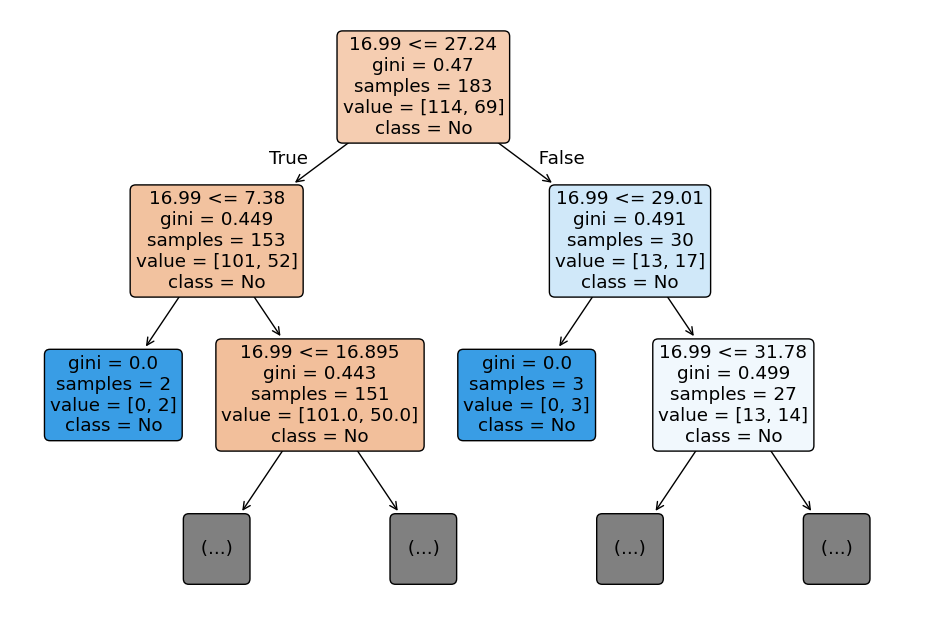

In [9]:
plt.figure(figsize=(12,8))

plot_tree(model_dt,
          feature_names= tipsdf['total_bill'], # input feature
          class_names= tipsdf['smoker'], # target feat
          max_depth=2,
          filled=True,
          rounded=True)

plt.show()

In [ ]:
29 2
17 1
